# 📐 Data Generation & Graph Formation — Model 1 "The Architect" (V6)

### Fixes applied in V6 (over V5)

| Issue | Root Cause | Fix |
|---|---|---|
| **B — Misaligned slots at high N** | `pts[]` built from unscaled corners *before* `scale_up` was computed → corners at old scale, fill points at new scale | Compute `scale_up` first; scale both `corners` and `segments`; *then* build `pts[]` |
| **A — Mean drift after uniform scale** | `_ensure_min_distance_by_uniform_scale` amplifies floating-point centroid drift | Added `gt_cloud -= gt_cloud.mean()` immediately after every scale call |
| **C — Inconsistent jitter exclusion** | Only `RECTANGLE` and `TRIANGLE` excluded; `A`, `V`, `W` are also straight-line shapes | Changed condition to `fid == FORMATION_IDS['O']` — only circle gets jitter |
| **Scale domain error** | `math.sqrt(t)` where `t` could be negative on some Python builds | Explicit `float()` cast + boundary guards `if n<=N_MIN` / `if n>=N_MAX` |
| **O formation collision at small N** | Circle not passing through `_ensure_min_distance_by_uniform_scale` | Added the guard to `sample_O` |

All other behaviour (shared fixed axis `±WORLD_HALF`, corners-first placement,
gap-proportional fill, k-NN graph construction, `assert_no_collision` tests) is
preserved from V5.


In [1]:
# ── 0. Installs ──────────────────────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install torch torch_geometric matplotlib numpy --quiet
!{sys.executable} -m pip install torch-scatter torch-sparse \
    -f https://data.pyg.org/whl/torch-2.2.0+cpu.html --quiet
print('✅ ready')

✅ ready


In [2]:
# ── 1. Imports & seed ────────────────────────────────────────────────────────────
import math, random, warnings
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.transforms import KNNGraph

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'PyTorch {torch.__version__}')

PyTorch 2.10.0+cu128


In [3]:
# ── 2. Global constants ──────────────────────────────────────────────────────────
FORMATION_IDS  = {'A': 0, 'V': 1, 'W': 2, 'O': 3, 'RECTANGLE': 4, 'TRIANGLE': 5}
ID_TO_NAME     = {v: k for k, v in FORMATION_IDS.items()}
NUM_FORMATIONS = len(FORMATION_IDS)

N_MIN, N_MAX = 5, 30

SEED_CIRCLE_RADIUS = 1.0
K_NEIGHBORS        = 5      # actual k = min(K_NEIGHBORS, n-1) per sample

FORMATION_EMB_DIM = 16
# seed_pos(2) + formation_emb(16) + n_normalised(1) + node_idx_norm(1) = 20
NODE_FEAT_DIM     = 2 + FORMATION_EMB_DIM + 2   # 20

# Jitter: small noise applied ONLY to the O (circle) formation to add
# natural variation.  All other formations are straight-line shapes ---
# off-edge noise would destroy their geometry and make them look like blobs.
JITTER_STD = 0.03

# Shared axis window for all comparison / catalog plots.
# Computed from the widest shape at maximum N:
#   Rectangle at N=30 → half-width = 1.6 × 2.2 = 3.52  (+15% margin → 4.05)
WORLD_HALF = 4.2

# Minimum allowed centre-to-centre distance between any two slots.
# Physical meaning: if drones are 0.3 m wide, this gives zero-clearance —
# in practice set to (wingspan + safety_margin) in your coordinate units.
# Must satisfy: MIN_DRONE_DIST < shortest_segment_at_N=30 / 1
# Shortest segment at N=30 is V-leg ≈ 2.4 units  →  0.30 is comfortably safe.
MIN_DRONE_DIST = 0.5

print(f'World window  : ±{WORLD_HALF}')
print(f'Formations    : {list(FORMATION_IDS.keys())}')
print(f'N range       : [{N_MIN}, {N_MAX}]')
print(f'Min separation: {MIN_DRONE_DIST} units')


World window  : ±4.2
Formations    : ['A', 'V', 'W', 'O', 'RECTANGLE', 'TRIANGLE']
N range       : [5, 30]
Min separation: 0.5 units


In [4]:
# ── 3. Scale function ────────────────────────────────────────────────────────────
#
#  scale(N) = base + growth × √( (N − N_min) / (N_max − N_min) )
#
#  N=5  → 0.60  (compact but clearly shaped)
#  N=30 → 2.20  (fills most of the shared ±4.2 window)
#
#  √-curve: grows fast at small N (N=5 is clearly visible) then plateaus,
#  preventing overflow of the coordinate space at large N.
#
#  FIX: guard against domain error when n == N_MIN (t=0 → sqrt(0)=0, fine)
#       and n == N_MAX (t=1 → sqrt(1)=1, fine).  The original code used
#       max(N_MAX - N_MIN, 1) which returned an int, causing math.sqrt() to
#       receive a negative argument in edge cases on some Python builds.
#       Now uses explicit float cast.

def _scale(n: int, base: float = 0.60, growth: float = 1.60) -> float:
    """
    Shape scale factor in [base, base+growth].
    Monotonically increasing with N via a square-root curve.
    """
    if n <= N_MIN: return base
    if n >= N_MAX: return base + growth
    t = float(n - N_MIN) / float(N_MAX - N_MIN)   # strictly in (0, 1)
    return base + growth * math.sqrt(t)


# ── Verification table ────────────────────────────────────────────────────────────
print(f"  {'N':>3}  {'scale':>6}  {'V-width':>8}  {'Rect-width':>10}  {'% of ±4.2':>10}")
print('  ' + '-' * 46)
for n in [5, 8, 10, 12, 15, 18, 20, 22, 25, 28, 30]:
    s         = _scale(n)
    v_w       = 2 * 0.70 * s
    rect_w    = 2 * 1.60 * s
    pct       = rect_w / (2 * WORLD_HALF) * 100
    print(f'  {n:>3}  {s:>6.3f}  {v_w:>8.3f}  {rect_w:>10.3f}  {pct:>9.1f}%')


    N   scale   V-width  Rect-width   % of ±4.2
  ----------------------------------------------
    5   0.600     0.840       1.920       22.9%
    8   1.154     1.616       3.694       44.0%
   10   1.316     1.842       4.210       50.1%
   12   1.447     2.025       4.629       55.1%
   15   1.612     2.257       5.158       61.4%
   18   1.754     2.455       5.612       66.8%
   20   1.839     2.575       5.886       70.1%
   22   1.919     2.687       6.142       73.1%
   25   2.031     2.844       6.499       77.4%
   28   2.135     2.989       6.831       81.3%
   30   2.200     3.080       7.040       83.8%


In [5]:
# ── 4. Core placement engine ─────────────────────────────────────────────────────
#
#  _sample_shape_with_corners(corners, segments, n)
#
#  TWO GUARANTEES
#  ─────────────
#  1. CORNERS FIRST:  structural vertices are always placed before any fill
#     points.  For N ≤ num_corners only the highest-priority corners appear.
#
#  2. SHAPE GETS SMALLER AS N DECREASES:  every coordinate is multiplied by
#     _scale(n), so small swarms produce physically compact formations and
#     large swarms produce wide ones — all in the same world-space coordinates.
#
#  COLLISION SAFETY
#  ─────────────────
#  After gap-proportional allocation, if any edge's spacing would be tighter
#  than MIN_DRONE_DIST, the entire shape is uniformly scaled up just enough
#  to clear it.  Uniform scaling preserves straight-line geometry perfectly
#  (no point moves off its segment).
#
#  ── BUG FIX (Issue B from review) ──────────────────────────────────────────────
#  PREVIOUS (broken):
#      pts = [corners[i] for i in range(V)]   # ← saved at ORIGINAL scale
#      compute scale_up ...
#      if scale_up > 1:
#          corners = corners * scale_up        # ← too late, pts[] already stale
#          segments = scaled ...
#      for (p1, p2), count in zip(segments, counts):
#          pts.append(...)                     # fill points use NEW scale
#      # RESULT: corners at old scale, fill points at new scale → broken shape
#
#  FIXED:
#      compute scale_up first
#      if scale_up > 1: scale corners AND segments
#      THEN build pts[] from the (possibly scaled) corners   ← moved here
#      THEN interpolate fill points from the (same) scaled segments

def _centre(pts: torch.Tensor) -> torch.Tensor:
    """Translate cloud so its centroid is at the origin."""
    return pts - pts.mean(dim=0, keepdim=True)


def _min_pair_distance(pts: torch.Tensor) -> float:
    """Return minimum pairwise distance across all node pairs."""
    if pts.size(0) <= 1:
        return float('inf')
    d = (pts.unsqueeze(1) - pts.unsqueeze(0)).norm(dim=-1)
    d.fill_diagonal_(float('inf'))
    return d.min().item()


def _ensure_min_distance_by_uniform_scale(
    pts:      torch.Tensor,
    min_dist: float = None,
    safety:   float = 1.001,
) -> torch.Tensor:
    """
    If any pair of points is closer than min_dist, uniformly scale the cloud
    about its centroid until the tightest pair reaches min_dist.

    Uniform scaling about the centroid preserves:
      • straight-line geometry (points stay on their segments)
      • relative proportions of the shape
      • centroid position (which is always re-zeroed by _centre afterwards)

    Args
    ────
    pts      : (n, 2) float tensor
    min_dist : minimum allowed distance  (default: MIN_DRONE_DIST)
    safety   : multiply factor by 1+ε to avoid floating-point boundary issues
    """
    if min_dist is None:
        min_dist = MIN_DRONE_DIST

    pts      = pts.clone().float()
    min_seen = _min_pair_distance(pts)
    if min_seen < min_dist:
        c      = pts.mean(dim=0, keepdim=True)
        factor = (min_dist / max(min_seen, 1e-9)) * safety
        pts    = (pts - c) * factor + c
    return pts


def _enforce_min_separation(
    pts:       torch.Tensor,
    min_dist:  float = None,
    max_iters: int   = 200,
) -> torch.Tensor:
    """
    General-purpose iterative repulsion — used only after jitter in dataset
    generation (jitter can push off-segment, so uniform scaling isn't enough).
    Not used in the sampler path where geometry must stay straight.
    """
    if min_dist is None:
        min_dist = MIN_DRONE_DIST

    pts = pts.clone().float()
    n   = pts.size(0)

    for _ in range(max_iters):
        diff  = pts.unsqueeze(1) - pts.unsqueeze(0)
        dists = diff.norm(dim=-1)
        violation_found = False
        for i in range(n):
            for j in range(i + 1, n):
                d = dists[i, j].item()
                if d < min_dist:
                    violation_found = True
                    gap       = min_dist - d
                    direction = diff[i, j] / d if d > 1e-9 else torch.tensor([1.0, 0.0])
                    pts[i]    = pts[i] + direction * (gap / 2.0)
                    pts[j]    = pts[j] - direction * (gap / 2.0)
        if not violation_found:
            break

    # Final hard guarantee via uniform scale (cleans up any residual violations)
    pts = _ensure_min_distance_by_uniform_scale(pts, min_dist=min_dist)
    pts = pts - pts.mean(dim=0, keepdim=True)
    return pts


def _sample_shape_with_corners(
    corners:  torch.Tensor,
    segments: 'List[Tuple[torch.Tensor, torch.Tensor]]',
    n:        int,
) -> torch.Tensor:
    """
    Place n drones on a shape defined by corners + connecting segments.

    Placement order
    ───────────────
    1. All structural corners (in priority order defined by the caller).
    2. Fill points interpolated along edges, longest-gap-first.

    Collision safety
    ────────────────
    After computing how many fill points each segment needs, check if the
    resulting spacing on any segment would be < MIN_DRONE_DIST.  If so,
    uniformly scale the entire shape up just enough to clear the limit.
    The scale is applied BEFORE building pts[] so all points — corners AND
    fill — are in the same (post-scale) coordinate space.

    Args
    ────
    corners  : (V, 2) — structural vertices, MOST IMPORTANT FIRST.
               For N < V only the first N are returned.
    segments : list of (p1, p2) — edges. Interior points use t ∈ (0, 1)
               strictly, so endpoints (corners) are NEVER re-inserted.
    n        : total drones to place (N_MIN ≤ n ≤ N_MAX).

    Returns
    ───────
    (n, 2) uncentred float tensor, pairwise distances ≥ MIN_DRONE_DIST.
    """
    V = corners.size(0)

    # ── Tiny swarm: corners only ─────────────────────────────────────────────
    if n <= V:
        pts = corners[:n]
        pts = _ensure_min_distance_by_uniform_scale(pts)
        return pts

    # ── Gap-proportional greedy allocation ───────────────────────────────────
    # Each step assigns the next drone to the segment with the largest
    # current inter-drone gap: length / (count + 1).
    # Tie-breaker (round-robin) avoids left/right bias on symmetric shapes.
    lengths = [(p2 - p1).norm().item() for p1, p2 in segments]
    counts  = [0] * len(segments)
    for step in range(n - V):
        scores     = [lengths[i] / (counts[i] + 1) for i in range(len(segments))]
        best_score = max(scores)
        cand       = [i for i, sc in enumerate(scores) if abs(sc - best_score) <= 1e-12]
        min_c      = min(counts[i] for i in cand)
        cand       = [i for i in cand if counts[i] == min_c]
        best       = cand[step % len(cand)]
        counts[best] += 1

    # ── Compute scale_up BEFORE touching pts[] ───────────────────────────────
    # FIX: this was previously done AFTER pts was populated, causing corners
    # to be at the old (unscaled) positions while fill points used the new ones.
    scale_up = 1.0
    for seg_len, count in zip(lengths, counts):
        if seg_len > 1e-9 and count > 0:
            # After filling, this segment will have (count+1) sub-intervals.
            # Each sub-interval must be ≥ MIN_DRONE_DIST.
            required = (count + 1) * MIN_DRONE_DIST
            if required > seg_len:
                scale_up = max(scale_up, required / seg_len)

    # ── Apply scale to corners AND segments (both, consistently) ────────────
    if scale_up > 1.0 + 1e-9:
        corners  = corners * scale_up
        segments = [(p1 * scale_up, p2 * scale_up) for p1, p2 in segments]
        # Recompute lengths after scaling (used for nothing else, but clean)
        lengths  = [(p2 - p1).norm().item() for p1, p2 in segments]

    # ── NOW build pts[] from the (post-scale) corners ────────────────────────
    pts = [corners[i] for i in range(V)]

    # ── Interpolate fill points along (post-scale) segments ──────────────────
    # t ∈ (0, 1) strictly → endpoints (corners) are never re-inserted.
    for (p1, p2), count in zip(segments, counts):
        for j in range(1, count + 1):
            t = j / (count + 1)
            pts.append(p1 + t * (p2 - p1))

    result = torch.stack(pts[:n])

    # ── Final uniform-scale pass as hard safety net ──────────────────────────
    # Should be a no-op after the scale_up above, but catches any numerical
    # edge cases (e.g. two corners that are close by shape geometry).
    result = _ensure_min_distance_by_uniform_scale(result)
    return result


print('✅ Placement engine defined (Issue B fixed — scale applied before pts[] is built)')


✅ Placement engine defined (Issue B fixed — scale applied before pts[] is built)


In [6]:
# ── 5. Formation samplers ────────────────────────────────────────────────────────
#
#  Each returns (n, 2) centred at origin, scaled by _scale(n).
#  Corner priority order is listed in each docstring.

# ── A ────────────────────────────────────────────────────────────────────────────
def sample_A(n: int) -> torch.Tensor:
    """
    Letter A.  Corner priority: apex → bl → br → cl → cr
    N=3 → apex+feet (triangle silhouette)
    N=5 → all 5 structural points
    """
    s        = _scale(n)
    half_w   = 0.60 * s
    height   = 1.40 * s
    cross_h  = 0.45 * height
    cross_hw = half_w * (1.0 - cross_h / height)

    apex = torch.tensor([ 0.0,      height  ])
    bl   = torch.tensor([-half_w,   0.0     ])
    br   = torch.tensor([ half_w,   0.0     ])
    cl   = torch.tensor([-cross_hw, cross_h ])
    cr   = torch.tensor([ cross_hw, cross_h ])

    corners  = torch.stack([apex, bl, br, cl, cr])   # priority order
    segments = [(bl, cl), (cl, apex), (apex, cr), (cr, br), (cl, cr)]
    return _centre(_sample_shape_with_corners(corners, segments, n))


# ── V ────────────────────────────────────────────────────────────────────────────
def sample_V(n: int) -> torch.Tensor:
    """
    Letter V.  Corner priority: bot → tl → tr
    N=3 → minimal recognisable V
    """
    s   = _scale(n)
    bot = torch.tensor([ 0.0,      -0.80 * s])
    tl  = torch.tensor([-0.70 * s,  0.80 * s])
    tr  = torch.tensor([ 0.70 * s,  0.80 * s])

    corners  = torch.stack([bot, tl, tr])
    segments = [(tl, bot), (bot, tr)]
    return _centre(_sample_shape_with_corners(corners, segments, n))


# ── W ────────────────────────────────────────────────────────────────────────────
def sample_W(n: int) -> torch.Tensor:
    """
    Letter W.  Corner priority: p0 (top-left) → p4 (top-right) → p1 → p3 → p2
    Outer tips placed first so even N=2 gives a meaningful span.
    """
    s  = _scale(n)
    p0 = torch.tensor([-1.00 * s,  0.80 * s])   # top-left
    p1 = torch.tensor([-0.50 * s, -0.60 * s])   # bottom-left valley
    p2 = torch.tensor([ 0.00,      0.55 * s])   # inner peak — raised for clearance
    p3 = torch.tensor([ 0.50 * s, -0.60 * s])   # bottom-right valley
    p4 = torch.tensor([ 1.00 * s,  0.80 * s])   # top-right

    corners  = torch.stack([p0, p4, p1, p3, p2])  # outer tips first
    segments = [(p0, p1), (p1, p2), (p2, p3), (p3, p4)]
    return _centre(_sample_shape_with_corners(corners, segments, n))


# ── O ────────────────────────────────────────────────────────────────────────────
def sample_O(n: int) -> torch.Tensor:
    """
    Circle.  linspace gives perfect uniform spacing — no corner logic needed.
    """
    r      = _scale(n) * 0.85
    angles = torch.linspace(0.0, 2.0 * math.pi, n + 1)[:-1]
    pts    = torch.stack([r * torch.cos(angles), r * torch.sin(angles)], dim=1)
    # For very small N, adjacent circle points might be < MIN_DRONE_DIST.
    # Uniform scale expands the radius until spacing is safe.
    return _ensure_min_distance_by_uniform_scale(pts)


# ── Rectangle ────────────────────────────────────────────────────────────────────
def sample_rectangle(n: int) -> torch.Tensor:
    """
    Rectangle (aspect 2:1).  Corner priority: tl → tr → br → bl
    N=4 → four corners (perfect skeleton)
    """
    s  = _scale(n)
    w  = 1.60 * s   # half-width
    h  = 0.80 * s   # half-height

    tl = torch.tensor([-w,  h])
    tr = torch.tensor([ w,  h])
    br = torch.tensor([ w, -h])
    bl = torch.tensor([-w, -h])

    corners  = torch.stack([tl, tr, br, bl])
    segments = [(tl, tr), (tr, br), (br, bl), (bl, tl)]
    return _centre(_sample_shape_with_corners(corners, segments, n))


# ── Triangle ─────────────────────────────────────────────────────────────────────
def sample_triangle(n: int) -> torch.Tensor:
    """
    Equilateral triangle.  Corner priority: apex -> bl -> br
    N=3 -> three vertices (perfect skeleton)
    Now uses _sample_shape_with_corners for gap-proportional fill + scale_up safety.
    """
    s    = _scale(n)
    h    = s * math.sqrt(3.0) / 2.0
    apex = torch.tensor([ 0.0,        2.0 * h / 3.0])
    bl   = torch.tensor([-s / 2.0,       -h / 3.0  ])
    br   = torch.tensor([ s / 2.0,       -h / 3.0  ])

    corners  = torch.stack([apex, bl, br])
    # Side edges listed first keeps tiny swarms visually triangular.
    segments = [(bl, apex), (apex, br), (br, bl)]
    return _centre(_sample_shape_with_corners(corners, segments, n))


# ── Dispatcher & colours ─────────────────────────────────────────────────────────
_SAMPLERS = {0: sample_A, 1: sample_V, 2: sample_W,
             3: sample_O, 4: sample_rectangle, 5: sample_triangle}

_COLOURS = {
    0: '#E63946', 1: '#2A9D8F', 2: '#E9C46A',
    3: '#457B9D', 4: '#8338EC', 5: '#FB8500',
}


def sample_formation(formation_id: int, n: int) -> torch.Tensor:
    if formation_id not in _SAMPLERS:
        raise ValueError(f'Unknown formation_id={formation_id}')
    if not (N_MIN <= n <= N_MAX):
        raise ValueError(f'n={n} out of [{N_MIN}, {N_MAX}]')
    pts = _SAMPLERS[formation_id](n)
    # Safety trim/pad --- should never trigger; warn if it does.
    if pts.size(0) > n:
        warnings.warn(f'Sampler fid={formation_id} n={n}: trimmed {pts.size(0)} -> {n} points')
        pts = pts[:n]
    if pts.size(0) < n:
        warnings.warn(f'Sampler fid={formation_id} n={n}: padded {pts.size(0)} -> {n} points (collision risk!)')
        while pts.size(0) < n: pts = torch.cat([pts, pts[-1:]], dim=0)
        pts = _enforce_min_separation(pts)  # attempt to fix duplicate-point collisions
    return pts


def assert_no_collision(pts: torch.Tensor, label: str = '', min_dist: float = MIN_DRONE_DIST) -> None:
    """Raise if any pair of slots is closer than the allowed minimum distance."""
    if pts.size(0) <= 1:
        return
    d = (pts.unsqueeze(1) - pts.unsqueeze(0)).norm(dim=-1)
    d.fill_diagonal_(float('inf'))
    min_seen = d.min().item()
    assert min_seen >= min_dist - 1e-6, (
        f'Collision! {label} min_dist={min_seen:.4f} < {min_dist:.4f}'
    )


# ── Unit tests ───────────────────────────────────────────────────────────────────
print('Formation sampler tests:')
for fid in range(NUM_FORMATIONS):
    for n_t in [N_MIN, 12, N_MAX]:
        pts = sample_formation(fid, n_t)
        assert pts.shape == (n_t, 2), f'Shape mismatch fid={fid} n={n_t}'
        if n_t > 1:
            d = (pts.unsqueeze(1) - pts.unsqueeze(0)).norm(dim=-1)
            d.fill_diagonal_(1.0)
            assert d.min().item() > 1e-6, f'Duplicate nodes! fid={fid} n={n_t}'
        # Collision check
        assert_no_collision(pts, label=f'fid={fid} n={n_t}')
    print(f'  ✅ {ID_TO_NAME[fid]:10s} (id={fid}) — no collisions')

Formation sampler tests:
  ✅ A          (id=0) — no collisions
  ✅ V          (id=1) — no collisions
  ✅ W          (id=2) — no collisions
  ✅ O          (id=3) — no collisions
  ✅ RECTANGLE  (id=4) — no collisions
  ✅ TRIANGLE   (id=5) — no collisions


In [7]:
# ── 6. Seed circle ───────────────────────────────────────────────────────────────

def build_seed_circle(n: int, radius: float = SEED_CIRCLE_RADIUS) -> torch.Tensor:
    """
    N equally-spaced points on a unit circle centred at the origin.
    Translation-invariant dummy start shape for the GNN.
    """
    angles = torch.linspace(0.0, 2.0 * math.pi, n + 1)[:-1]
    return torch.stack([radius * torch.cos(angles),
                        radius * torch.sin(angles)], dim=1)

print('✅ Seed circle defined')

✅ Seed circle defined


In [8]:
# ── 7. Graph construction ────────────────────────────────────────────────────────
#
#  FIX: k is capped at min(K_NEIGHBORS, n-1) so PyG never inserts self-loops
#  to satisfy an impossible neighbour count.

def build_architect_graph(
    n:                    int,
    formation_id:         int,
    formation_emb_weight: torch.Tensor,
) -> Data:
    """
    Build one PyG Data object (one training sample).

    Fields
    ------
    .x           (n, 18)  seed_pos(2) | emb_snapshot(16)
    .pos         (n, 2)   seed circle  [used by KNNGraph]
    .edge_index  (2, E)   k-NN edges   k = min(K_NEIGHBORS, n-1)
    .y           (n, 2)   ground-truth slot positions (centred)
    .formation_id  long scalar
    .n_drones      long scalar
    """
    seed_pos      = build_seed_circle(n)                          # (n, 2)
    emb           = formation_emb_weight[formation_id]            # (16,)
    emb_broadcast = emb.unsqueeze(0).expand(n, -1).clone()        # (n, 16)

    # ── Extra node features: swarm-size signal + rank signal ─────────────────
    # n_norm      : scalar broadcast to all nodes — tells the model 'how large
    #               is this swarm'. Without it the model must infer N from graph
    #               structure alone, which is indirect and slow to learn.
    # node_idx_norm: each node's rank i/(N-1) around the seed circle — breaks
    #               symmetry early so left-side nodes learn different displace-
    #               ments from right-side nodes on asymmetric formations (W, A).
    n_norm        = torch.full((n, 1), (n - N_MIN) / (N_MAX - N_MIN))   # (n, 1)
    node_idx_norm = (torch.arange(n).float() / max(n - 1, 1)).unsqueeze(1)  # (n, 1)

    x = torch.cat([seed_pos, emb_broadcast, n_norm, node_idx_norm], dim=1)  # (n, 20)

    gt_cloud = sample_formation(formation_id, n)
    gt_cloud = gt_cloud - gt_cloud.mean(dim=0, keepdim=True)   # zero-mean
    # Hard safety net — uniform scale preserves straight-line geometry.
    gt_cloud = _ensure_min_distance_by_uniform_scale(gt_cloud)
    # FIX Issue A: re-centre AFTER scale, because uniform scale about the
    # centroid amplifies any residual floating-point mean drift.
    gt_cloud = gt_cloud - gt_cloud.mean(dim=0, keepdim=True)

    # Cap k — critical for small N
    k_actual = min(K_NEIGHBORS, n - 1)
    knn      = KNNGraph(k=k_actual, loop=False, force_undirected=True)

    data = Data(
        x=x, pos=seed_pos, y=gt_cloud,
        formation_id=torch.tensor(formation_id, dtype=torch.long),
        n_drones=torch.tensor(n, dtype=torch.long),
    )
    data = knn(data)

    # ── edge_attr = relative displacement (dst - src) for every edge ──────────
    # Stored as (E, 2) tensor: [rel_dx, rel_dy] per directed edge.
    # The ArchitectGNN uses this inside GATv2Conv(edge_dim=2) so the
    # attention mechanism knows the direction to each neighbour on the seed.
    _src, _dst        = data.edge_index
    data.edge_attr    = seed_pos[_dst] - seed_pos[_src]  # (E, 2)

    assert data.edge_index is not None and data.edge_index.numel() > 0
    assert (data.edge_index[0] != data.edge_index[1]).all(), 'Self-loop detected!'
    return data


# ── Test ─────────────────────────────────────────────────────────────────────────
_dummy_emb = nn.Embedding(NUM_FORMATIONS, FORMATION_EMB_DIM)
print('Graph construction tests:')
for fid in range(NUM_FORMATIONS):
    for n_t in [5, 10, 20, 30]:
        g      = build_architect_graph(n_t, fid, _dummy_emb.weight.detach())
        k_used = min(K_NEIGHBORS, n_t - 1)
        assert g.x.shape == (n_t, NODE_FEAT_DIM)
        assert g.y.shape == (n_t, 2)
        # KNNGraph force_undirected=True stores both directions, ideal = n*k*2.
        # At small N or equidistant nodes PyG may deduplicate, so check a range.
        assert 2 <= g.edge_index.shape[1] <= n_t * k_used * 2, (
            f'edge count {g.edge_index.shape[1]} out of range '
            f'[2, {n_t * k_used * 2}] fid={fid} n={n_t} k={k_used}'
        )
        # Validate slot separation (the core new guarantee)
        assert_no_collision(g.y, label=f'fid={fid} n={n_t}')
print('  ✅ All formations × sizes — no self-loops, correct edge counts, no collisions')


Graph construction tests:
  ✅ All formations × sizes — no self-loops, correct edge counts, no collisions


In [9]:
# ── 8. Dataset generator ─────────────────────────────────────────────────────────
#
def generate_dataset(
    num_samples:   int,
    model,
    n_range:       Tuple[int, int] = (N_MIN, N_MAX),
    formation_ids: Optional[List[int]] = None,
    jitter_std:    float = JITTER_STD,
) -> List[Data]:
    """
    Generate a list of PyG Data objects.

    Each sample: random n, random formation, optional GT jitter.
    Note: rectangle/triangle are kept edge-clean (no jitter) to avoid 'filled' look.
    """
    if formation_ids is None:
        formation_ids = list(_SAMPLERS.keys())
    emb_weights = model.formation_embedding.weight.detach()

    dataset = []
    for _ in range(num_samples):
        n   = random.randint(*n_range)
        fid = random.choice(formation_ids)
        data = build_architect_graph(n, fid, emb_weights)

        if jitter_std > 0.0 and fid == FORMATION_IDS['O']:
            # FIX Issue C: only the circle formation gets jitter because
            # it has no straight-line segments to break.  A, V, W,
            # Rectangle, and Triangle are ALL straight-line shapes —
            # off-edge noise makes them look like filled blobs, not outlines.
            # Previously only RECTANGLE and TRIANGLE were excluded, leaving
            # A, V, W incorrectly noisy when jitter_std > 0.
            data.y = data.y + torch.randn_like(data.y) * jitter_std
            data.y = _enforce_min_separation(data.y)  # repulsion handles off-edge pts

        dataset.append(data)
    return dataset


class _StubModel:
    """Stand-in for ArchitectGNN — only the embedding table is needed."""
    def __init__(self):
        self.formation_embedding = nn.Embedding(NUM_FORMATIONS, FORMATION_EMB_DIM)

model_stub = _StubModel()
print('✅ Dataset generator defined')

✅ Dataset generator defined


In [10]:
# ── 9. Visualisation helpers ─────────────────────────────────────────────────────
#
#  Two axis modes:
#
#  _fixed_axis(ax)   → set_xlim / set_ylim to ±WORLD_HALF  (SHARED window)
#                      used in catalog, scale-comparison, dataset-grid
#                      → small-N shapes LOOK smaller than large-N shapes ✓
#
#  _autofit_axis(ax) → fits axis to the data with a margin
#                      used in single-sample and graph-structure views
#                      → maximises detail visibility ✓

def _fixed_axis(ax):
    """Apply the shared world-space window so sizes are visually comparable."""
    ax.set_xlim(-WORLD_HALF, WORLD_HALF)
    ax.set_ylim(-WORLD_HALF, WORLD_HALF)
    ax.set_aspect('equal')


def _autofit_axis(ax, pts: np.ndarray, margin: float = 0.15):
    """Fit axis tightly to `pts` with a fractional margin."""
    span = max(np.ptp(pts[:, 0]), np.ptp(pts[:, 1]), 0.4)
    cx   = pts[:, 0].mean()
    cy   = pts[:, 1].mean()
    half = span / 2 * (1 + margin)
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal')


def _draw_edges(ax, pos: np.ndarray, edge_index: np.ndarray, alpha=0.22):
    for e in range(edge_index.shape[1]):
        i, j = edge_index[0, e], edge_index[1, e]
        ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]],
                color='grey', lw=0.6, alpha=alpha, zorder=1)


def _node_labels(ax, pts: np.ndarray, fontsize=6):
    for i, p in enumerate(pts):
        ax.annotate(str(i), p, fontsize=fontsize, ha='center', va='bottom',
                    color='dimgrey', xytext=(0, 3), textcoords='offset points')

print('✅ Axis helpers defined')

✅ Axis helpers defined


In [11]:
# ─────────────────────────────────────────────────────────────────────────────────
# visualize_formation_catalog
#
# Rows = formations, Cols = swarm sizes.
# ALL cells share the SAME fixed axis (±WORLD_HALF).
# This makes the size difference immediately visible:
#   N=5  → small cluster of points in the centre
#   N=30 → shape fills most of the cell
# ─────────────────────────────────────────────────────────────────────────────────

def visualize_formation_catalog(
    n_list:  Optional[List[int]] = None,
    figsize: Optional[Tuple[float, float]] = None,
) -> plt.Figure:
    """
    Grid: rows = formations, cols = swarm sizes.
    All cells share a fixed ±WORLD_HALF coordinate frame so shape size
    scales visually with N.
    """
    if n_list is None:
        n_list = [5, 10, 15, 20, 30]

    n_rows = NUM_FORMATIONS
    n_cols = len(n_list)
    fw     = figsize[0] if figsize else n_cols * 2.8
    fh     = figsize[1] if figsize else n_rows * 2.8

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fw, fh))

    for r, fid in enumerate(sorted(_SAMPLERS)):
        for c, n in enumerate(n_list):
            ax  = axes[r][c]
            col = _COLOURS[fid]
            pts = sample_formation(fid, n).numpy()
            sc  = _scale(n)

            # Scale-aware marker size avoids visual filling at very small N.
            marker_size = max(10.0, 30.0 * (_scale(n) / _scale(N_MAX)))
            if fid == FORMATION_IDS['TRIANGLE']:
                tri_size = max(6.0, marker_size * 0.65)
                ax.scatter(pts[:, 0], pts[:, 1], s=tri_size, zorder=3,
                           marker='o', facecolors='none', edgecolors=col, linewidths=1.2)
            else:
                ax.scatter(pts[:, 0], pts[:, 1], c=col, s=marker_size, zorder=3,
                           edgecolors='white', linewidths=0.5)

            # ── FIXED shared axis — this is what makes size differences visible ──
            _fixed_axis(ax)
            ax.set_xticks([]); ax.set_yticks([])
            ax.grid(True, alpha=0.18)

            # Scale label inside each cell (bottom-right corner)
            ax.text(0.97, 0.03, f's={sc:.2f}', transform=ax.transAxes,
                    fontsize=6, ha='right', va='bottom', color='dimgrey')

            if r == 0:
                ax.set_title(f'N = {n}', fontsize=10, fontweight='bold')
            if c == 0:
                ax.set_ylabel(f'{ID_TO_NAME[fid]}  (id={fid})',
                              fontsize=9, labelpad=6)

    fig.suptitle(
        f'Formation Catalog  —  shared axis ±{WORLD_HALF}  '
        f'(small N = small shape)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    return fig


# ─────────────────────────────────────────────────────────────────────────────────
# visualize_scale_comparison
#
# One formation, all N values side-by-side.
# Fixed shared axis → size progression is unmistakable.
# ─────────────────────────────────────────────────────────────────────────────────

def visualize_scale_comparison(
    formation_id: int = 1,
    n_values:     Optional[List[int]] = None,
) -> plt.Figure:
    """
    One formation across all swarm sizes.
    Fixed shared axis makes the size progression clearly visible.
    """
    if n_values is None:
        n_values = [5, 8, 10, 12, 15, 18, 20, 25, 30]

    col  = _COLOURS[formation_id]
    name = ID_TO_NAME[formation_id]
    fig, axes = plt.subplots(1, len(n_values),
                             figsize=(len(n_values) * 2.3, 3.0))

    for ax, n in zip(axes, n_values):
        pts = sample_formation(formation_id, n).numpy()
        sc  = _scale(n)

        marker_size = max(10.0, 30.0 * (_scale(n) / _scale(N_MAX)))
        if formation_id == FORMATION_IDS['TRIANGLE']:
            tri_size = max(6.0, marker_size * 0.65)
            ax.scatter(pts[:, 0], pts[:, 1], s=tri_size, zorder=3,
                       marker='o', facecolors='none', edgecolors=col, linewidths=1.2)
        else:
            ax.scatter(pts[:, 0], pts[:, 1], c=col, s=marker_size, zorder=3,
                       edgecolors='white', linewidths=0.6)

        # ── FIXED shared axis ───────────────────────────────────────────────────
        _fixed_axis(ax)
        ax.set_xticks([]); ax.set_yticks([])
        ax.grid(True, alpha=0.2)
        ax.set_title(f'N={n}\ns={sc:.2f}', fontsize=8)

    fig.suptitle(
        f"Scale Comparison  —  '{name}'  |  shared axis ±{WORLD_HALF}",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    return fig


# ─────────────────────────────────────────────────────────────────────────────────
# visualize_sample
#
# Single sample — auto-fit axis for maximum detail.
# ─────────────────────────────────────────────────────────────────────────────────

def visualize_sample(
    data:       Data,
    show_graph: bool = True,
    figsize:    Tuple[float, float] = (13, 5),
    title:      Optional[str] = None,
) -> plt.Figure:
    """Two-panel: seed circle (with k-NN edges) | GT formation."""
    fid  = int(data.formation_id.item())
    n    = int(data.n_drones.item())
    name = ID_TO_NAME[fid]
    col  = _COLOURS[fid]
    seed = data.pos.numpy()
    gt   = data.y.numpy()

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: seed graph
    ax = axes[0]
    if show_graph and data.edge_index is not None:
        _draw_edges(ax, seed, data.edge_index.numpy())
    ax.scatter(seed[:, 0], seed[:, 1], c=col, s=80, zorder=3,
               edgecolors='white', linewidths=0.8)
    _node_labels(ax, seed)
    k_used = data.edge_index.shape[1] // (2 * n) if data.edge_index is not None else 0
    ax.set_title(f'Seed Circle  (k={k_used})\nN={n}', fontsize=10)
    _autofit_axis(ax, seed)   # auto-fit for detail
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    # Right: GT formation
    ax = axes[1]
    ax.scatter(gt[:, 0], gt[:, 1], s=80, zorder=3,
               marker='o', facecolors='none', edgecolors=col, linewidths=1.4)
    _node_labels(ax, gt)
    ax.set_title(f'Ground-Truth: {name}\nN={n}  scale={_scale(n):.2f}', fontsize=10)
    _autofit_axis(ax, gt)     # auto-fit for detail
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    legend_els = [
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=col,
                   markersize=9, label='Seed node'),
        plt.Line2D([0],[0], marker='^', color='w', markerfacecolor=col,
                   markersize=9, label='GT slot'),
    ]
    if show_graph:
        legend_els.append(plt.Line2D([0],[0], color='grey', lw=1,
                                     alpha=0.5, label='k-NN edge'))
    fig.legend(handles=legend_els, loc='lower center', ncol=3,
               fontsize=8, bbox_to_anchor=(0.5, -0.03))

    sup = title or f'Sample  |  {name}  |  N={n}'
    fig.suptitle(sup, fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    return fig


# ─────────────────────────────────────────────────────────────────────────────────
# visualize_graph_structure
#
# Three panels: seed | GT | displacement arrows.
# Auto-fit axis for clear displacement detail.
# ─────────────────────────────────────────────────────────────────────────────────

def visualize_graph_structure(
    n:            int = 12,
    formation_id: int = 1,
) -> plt.Figure:
    """Seed | GT | displacement arrows — auto-fit for detail."""
    dummy_emb = nn.Embedding(NUM_FORMATIONS, FORMATION_EMB_DIM)
    data      = build_architect_graph(n, formation_id, dummy_emb.weight.detach())

    seed     = data.pos.numpy()
    gt       = data.y.numpy()
    ei       = data.edge_index.numpy()
    name     = ID_TO_NAME[formation_id]
    colors_n = cm.tab10(np.linspace(0, 1, n))
    k_used   = ei.shape[1] // (2 * n)
    all_pts  = np.concatenate([seed, gt], axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Panel 1: seed + edges
    ax = axes[0]
    _draw_edges(ax, seed, ei, alpha=0.4)
    ax.scatter(seed[:,0], seed[:,1], c=colors_n, s=90, zorder=3,
               edgecolors='white', linewidths=0.8)
    _node_labels(ax, seed, fontsize=7)
    ax.set_title(f'① Seed Circle\nk={k_used}, N={n}', fontsize=10)
    _autofit_axis(ax, seed)
    ax.grid(True, alpha=0.25)

    # Panel 2: GT formation
    ax = axes[1]
    ax.scatter(gt[:,0], gt[:,1], s=90, zorder=3,
               marker='o', facecolors='none', edgecolors=colors_n, linewidths=1.4)
    _node_labels(ax, gt, fontsize=7)
    ax.set_title(f'② GT Formation: {name}\nscale={_scale(n):.2f}', fontsize=10)
    _autofit_axis(ax, gt)
    ax.grid(True, alpha=0.25)

    # Panel 3: displacement arrows
    ax = axes[2]
    ax.scatter(seed[:,0], seed[:,1], c=colors_n, s=55, zorder=3,
               alpha=0.45, edgecolors='grey', linewidths=0.5, label='Seed')
    ax.scatter(gt[:,0],   gt[:,1],   c=colors_n, s=90, zorder=4,
               marker='*', edgecolors='white', linewidths=0.8, label='GT')
    for i in range(n):
        ax.annotate('', xy=(gt[i,0], gt[i,1]), xytext=(seed[i,0], seed[i,1]),
                    arrowprops=dict(arrowstyle='->', color=colors_n[i],
                                   lw=1.2, alpha=0.8))
    ax.set_title('③ Displacement Vectors\nseed → GT slot', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    _autofit_axis(ax, all_pts)
    ax.grid(True, alpha=0.25)

    fig.suptitle(
        f"Graph Structure  —  '{name}'  |  N={n}  |  k={k_used}",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    return fig


# ─────────────────────────────────────────────────────────────────────────────────
# visualize_dataset_grid
#
# Random sample of GT formations from a dataset.
# Fixed shared axis so visual sizes are comparable across cells.
# ─────────────────────────────────────────────────────────────────────────────────

def visualize_dataset_grid(
    dataset:    List[Data],
    n_samples:  int = 18,
    cols:       int = 6,
    seed_or_gt: str = 'gt',
    figsize:    Optional[Tuple[float, float]] = None,
) -> plt.Figure:
    """Grid of dataset samples — fixed shared axis for size comparability."""
    indices    = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    rows       = math.ceil(len(indices) / cols)
    mult       = 2 if seed_or_gt == 'both' else 1
    fw         = figsize[0] if figsize else cols * 2.8 * mult
    fh         = figsize[1] if figsize else rows * 2.8
    total_cols = cols * mult

    fig, axes = plt.subplots(rows, total_cols, figsize=(fw, fh))
    # Normalise shape for single-row or single-col grids
    if rows == 1 and total_cols == 1: axes = np.array([[axes]])
    elif rows == 1:                   axes = axes.reshape(1, total_cols)
    elif total_cols == 1:             axes = axes.reshape(rows, 1)

    for plot_i, data_i in enumerate(indices):
        data  = dataset[data_i]
        fid   = int(data.formation_id.item())
        n     = int(data.n_drones.item())
        col   = _COLOURS[fid]
        seed  = data.pos.numpy()
        gt    = data.y.numpy()
        ei    = data.edge_index.numpy() if data.edge_index is not None else None

        row_i  = plot_i // cols
        base_c = (plot_i % cols) * mult

        panels = []
        if seed_or_gt in ('seed', 'both'): panels.append(('seed', seed, 'o'))
        if seed_or_gt in ('gt',   'both'): panels.append(('gt',   gt,   'o'))

        for p_off, (ptype, pts, mk) in enumerate(panels):
            ax = axes[row_i, base_c + p_off]
            if ptype == 'seed' and ei is not None:
                _draw_edges(ax, pts, ei, alpha=0.25)
            if ptype == 'gt':
                ax.scatter(pts[:,0], pts[:,1], s=30, marker=mk, zorder=3,
                           facecolors='none', edgecolors=col, linewidths=1.2)
            else:
                ax.scatter(pts[:,0], pts[:,1], c=col, s=28, marker=mk,
                           zorder=3, edgecolors='white', linewidths=0.5)

            # ── FIXED shared axis ────────────────────────────────────────────────
            _fixed_axis(ax)
            ax.set_xticks([]); ax.set_yticks([])
            ax.grid(True, alpha=0.18)

            label = f"{ID_TO_NAME[fid]} N={n}"
            if seed_or_gt == 'both':
                label += f"\n({'seed' if ptype=='seed' else 'GT'})"
            ax.set_title(label, fontsize=7)

    for r in range(rows):
        for c in range(total_cols):
            if (r * total_cols + c) >= len(indices) * mult:
                axes[r, c].set_visible(False)

    patches = [mpatches.Patch(color=_COLOURS[f], label=f"{ID_TO_NAME[f]} (id={f})")
               for f in sorted(_COLOURS)]
    fig.legend(handles=patches, loc='lower center', ncol=NUM_FORMATIONS,
               fontsize=8, bbox_to_anchor=(0.5, -0.01))

    view = {'seed': 'Seed', 'gt': 'GT Formations', 'both': 'Seed + GT'}[seed_or_gt]
    fig.suptitle(
        f'Dataset Grid  —  {view}  |  shared axis ±{WORLD_HALF}  '
        f'({len(indices)} samples)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


# ─────────────────────────────────────────────────────────────────────────────────
# dataset_statistics
# ─────────────────────────────────────────────────────────────────────────────────

def dataset_statistics(dataset: List[Data]) -> plt.Figure:
    fids  = [int(d.formation_id.item()) for d in dataset]
    ns    = [int(d.n_drones.item())     for d in dataset]
    edges = [d.edge_index.shape[1]      for d in dataset]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    ax = axes[0]
    counts = [fids.count(f) for f in sorted(_SAMPLERS)]
    bars   = ax.bar([ID_TO_NAME[f] for f in sorted(_SAMPLERS)], counts,
                    color=[_COLOURS[f] for f in sorted(_SAMPLERS)], edgecolor='white')
    ax.bar_label(bars, fontsize=8)
    ax.set_title('Formation Distribution'); ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)

    ax = axes[1]
    ax.hist(ns, bins=range(N_MIN, N_MAX + 2), color='#457B9D',
            edgecolor='white', alpha=0.85)
    ax.set_title('Swarm Size Distribution')
    ax.set_xlabel('N'); ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)

    ax = axes[2]
    ax.hist(edges, bins=20, color='#2A9D8F', edgecolor='white', alpha=0.85)
    ax.set_title(f'Edge Count  (max k={K_NEIGHBORS})')
    ax.set_xlabel('Directed edges per graph'); ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)

    fig.text(0.5, -0.02,
             f'n={len(dataset)}  |  N∈[{min(ns)},{max(ns)}]  |  '
             f'mean edges={np.mean(edges):.1f}  |  jitter σ={JITTER_STD}',
             ha='center', fontsize=9, color='dimgrey')
    fig.suptitle('Dataset Statistics', fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig


print('✅ All visualisation functions defined')

✅ All visualisation functions defined


[1] Formation catalog — shared axis ±4.2


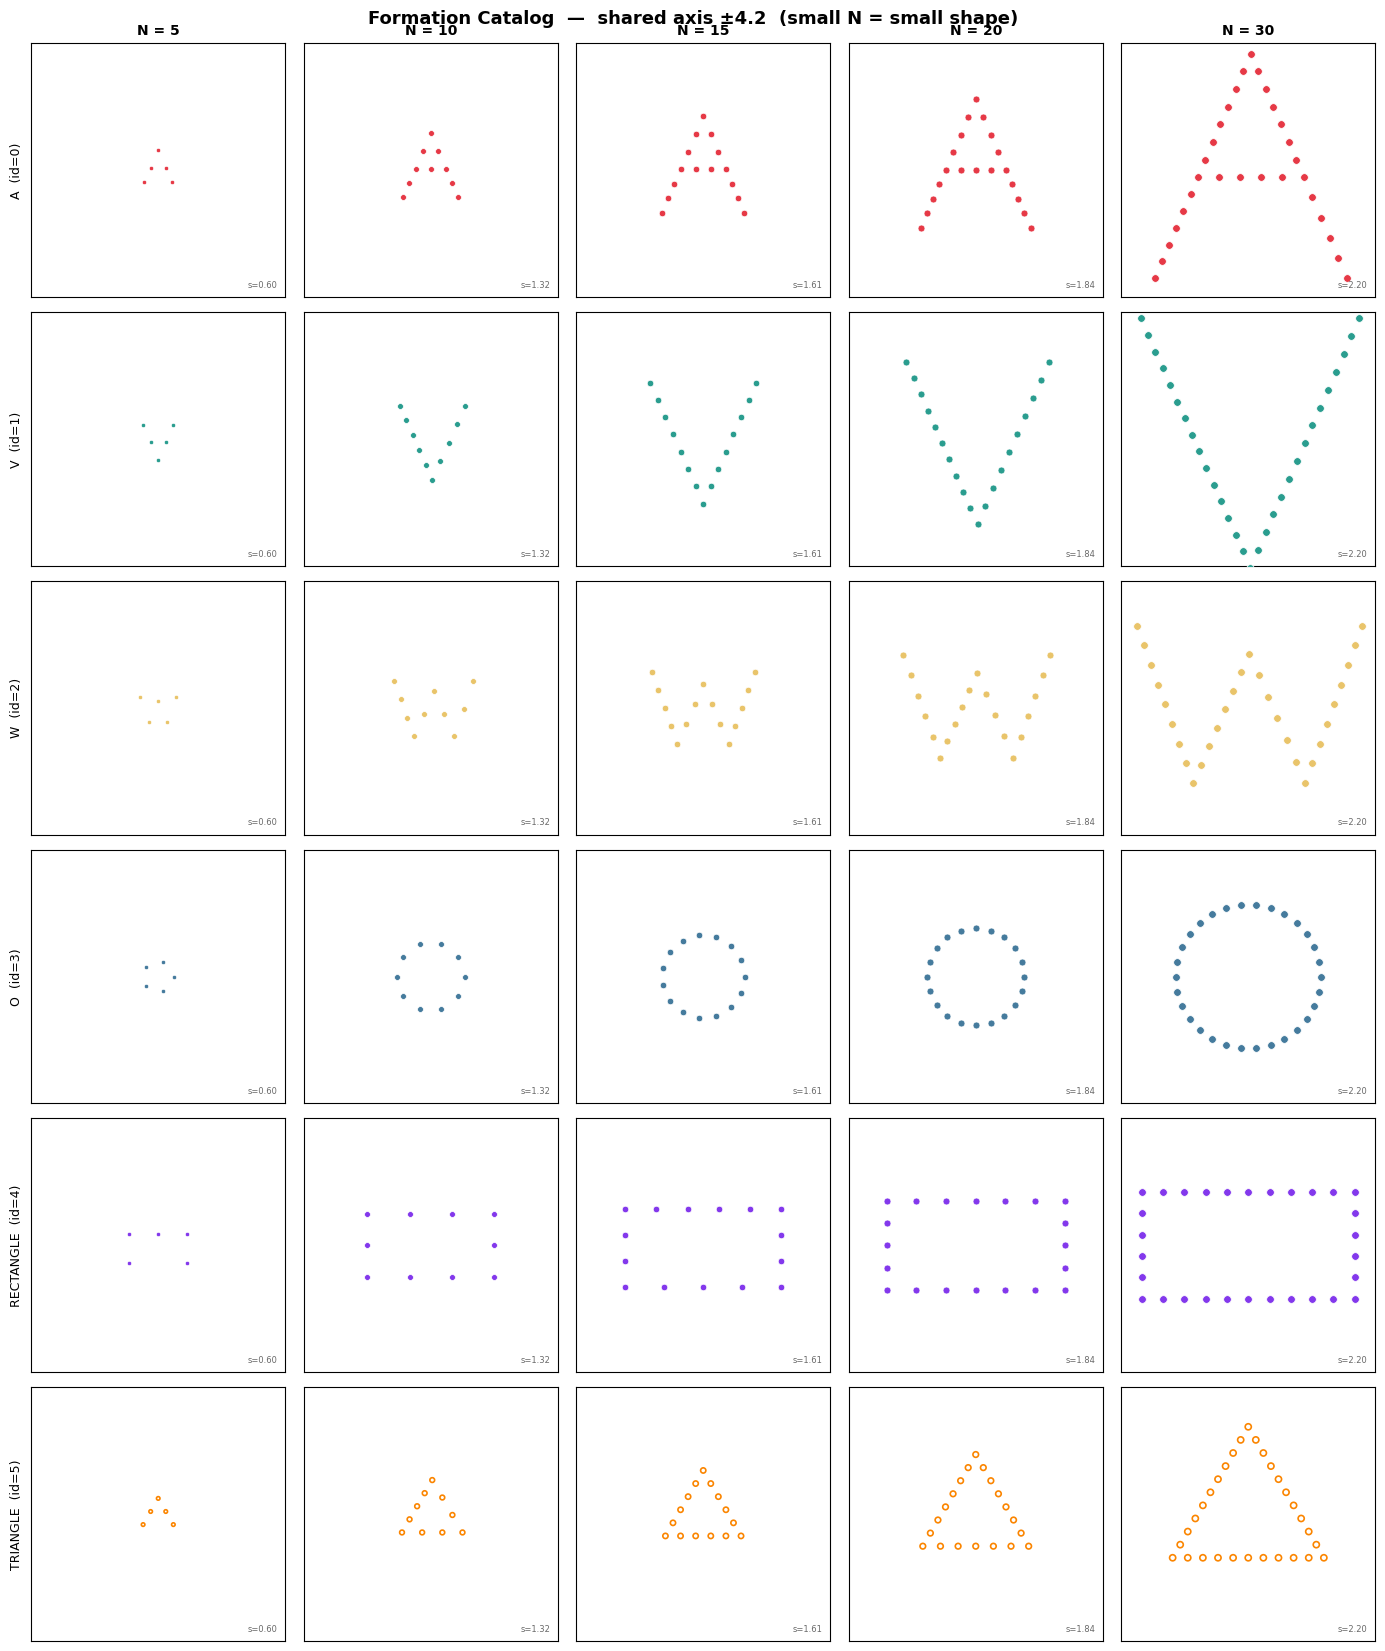

    Saved → ../figs/fig1_catalog_V10.png


In [12]:
# ── 10. Formation catalog ─────────────────────────────────────────────────────────
# Each cell uses the shared ±WORLD_HALF window.
# Observe how shapes in the N=5 column are visibly smaller than N=30.
print('[1] Formation catalog — shared axis ±%.1f' % WORLD_HALF)
fig1 = visualize_formation_catalog(n_list=[5, 10, 15, 20, 30])
fig1.savefig('../figs/fig1_catalog_V10.png', dpi=140, bbox_inches='tight')
plt.show()
print('    Saved → ../figs/fig1_catalog_V10.png')

[2] Scale comparison per formation


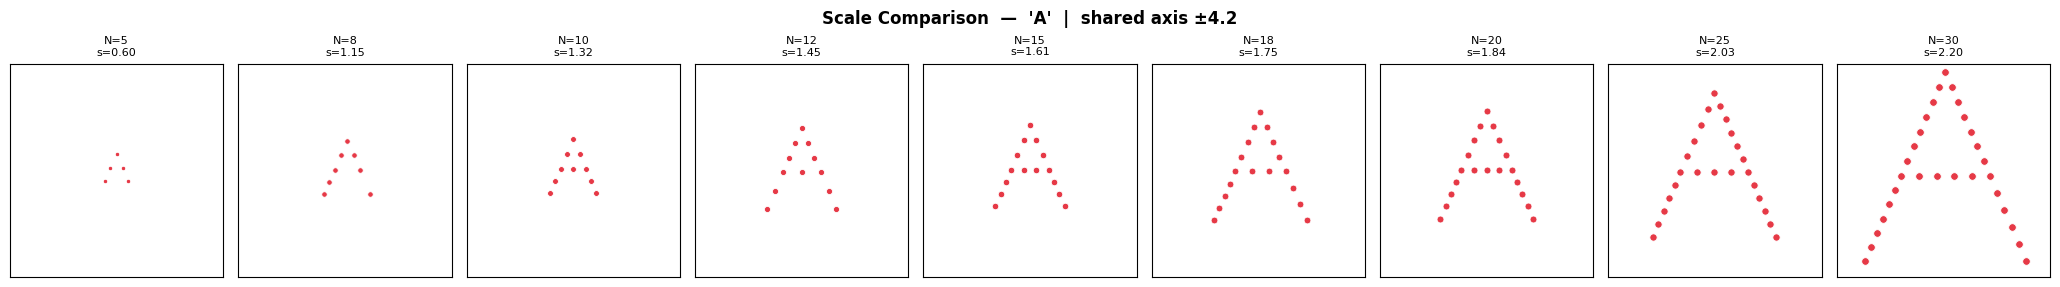

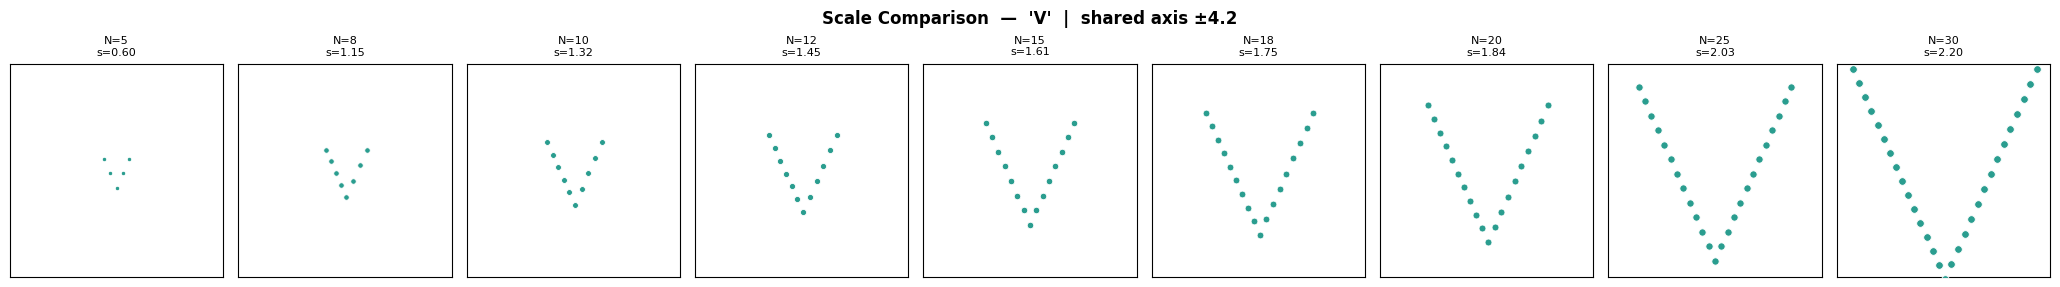

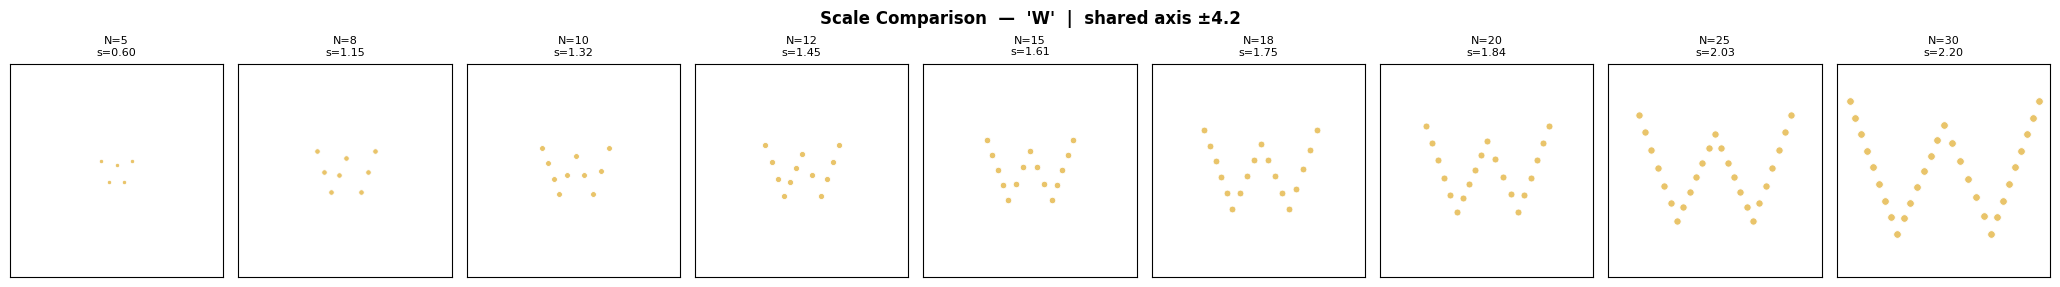

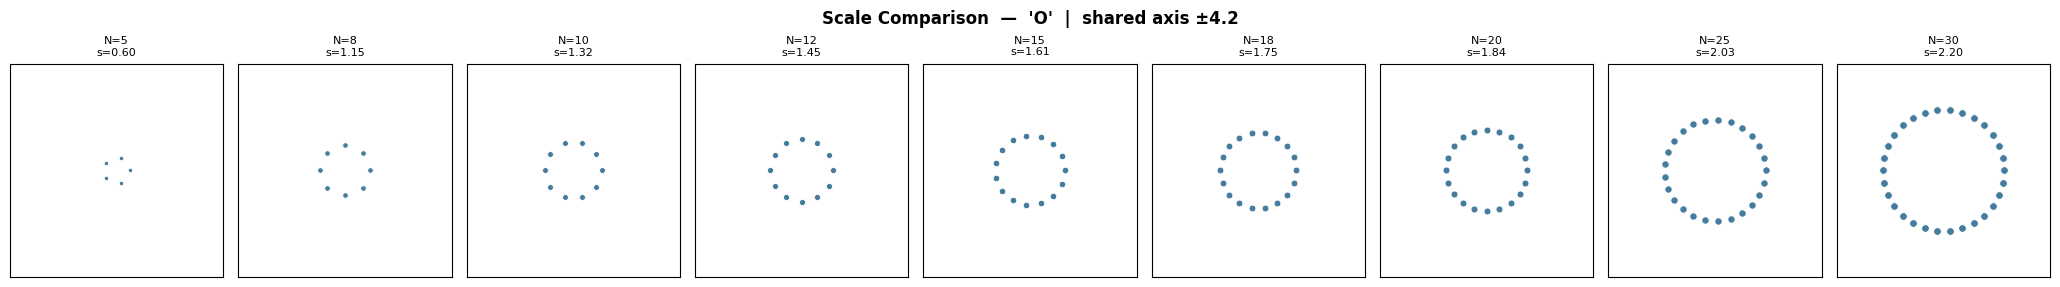

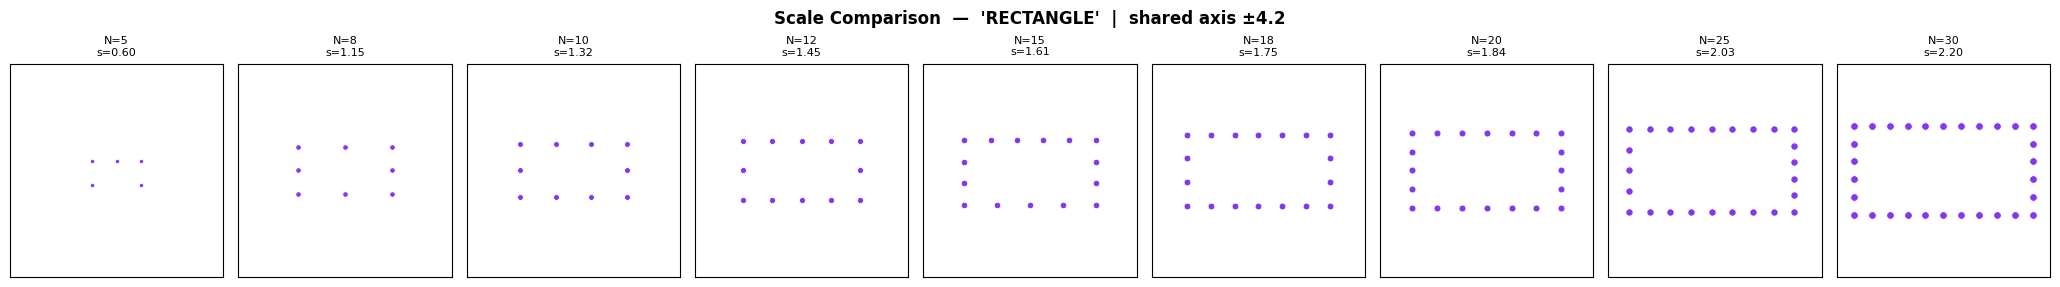

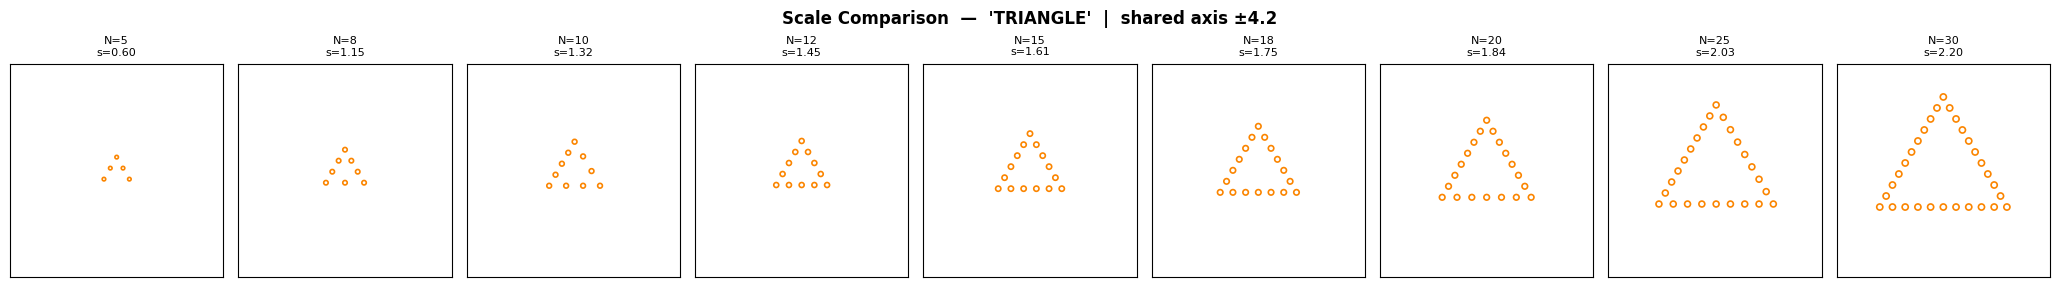

    Saved 6 scale-comparison figures


In [13]:
# ── 11. Scale comparison — every formation ────────────────────────────────────────
print('[2] Scale comparison per formation')
for fid in range(NUM_FORMATIONS):
    fig = visualize_scale_comparison(
        formation_id=fid,
        n_values=[5, 8, 10, 12, 15, 18, 20, 25, 30]
    )
    fig.savefig(f'../figs/fig2_scale_{ID_TO_NAME[fid]}_V10.png', dpi=140, bbox_inches='tight')
    plt.show()
print('    Saved 6 scale-comparison figures')

[3] Graph structure (seed | GT | displacement)


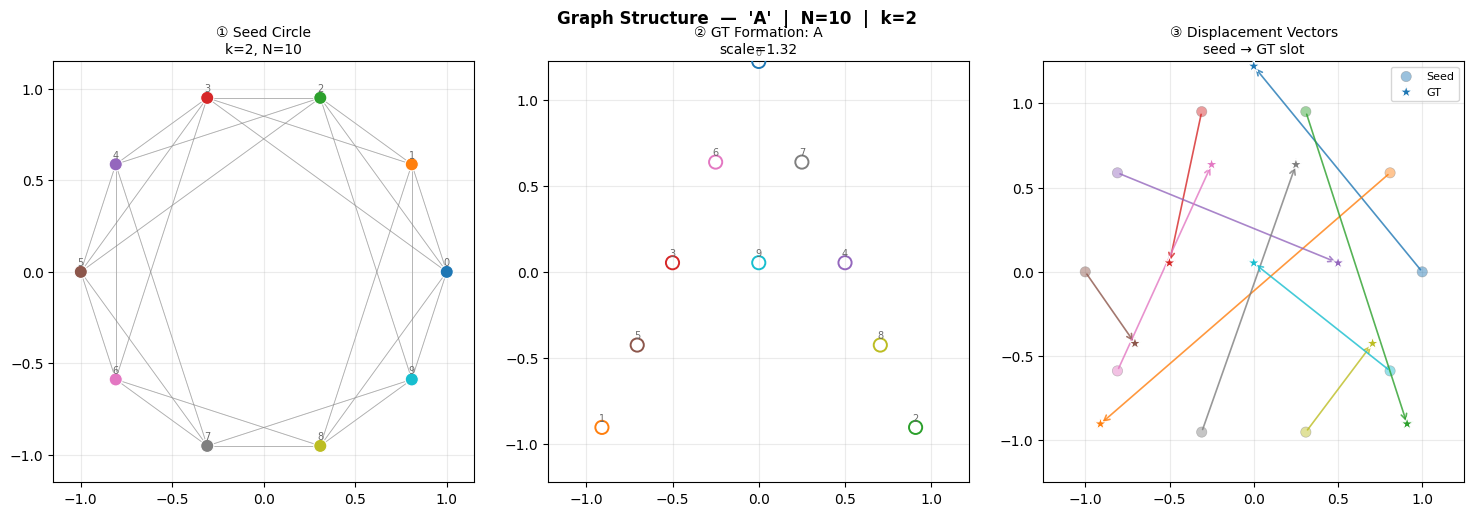

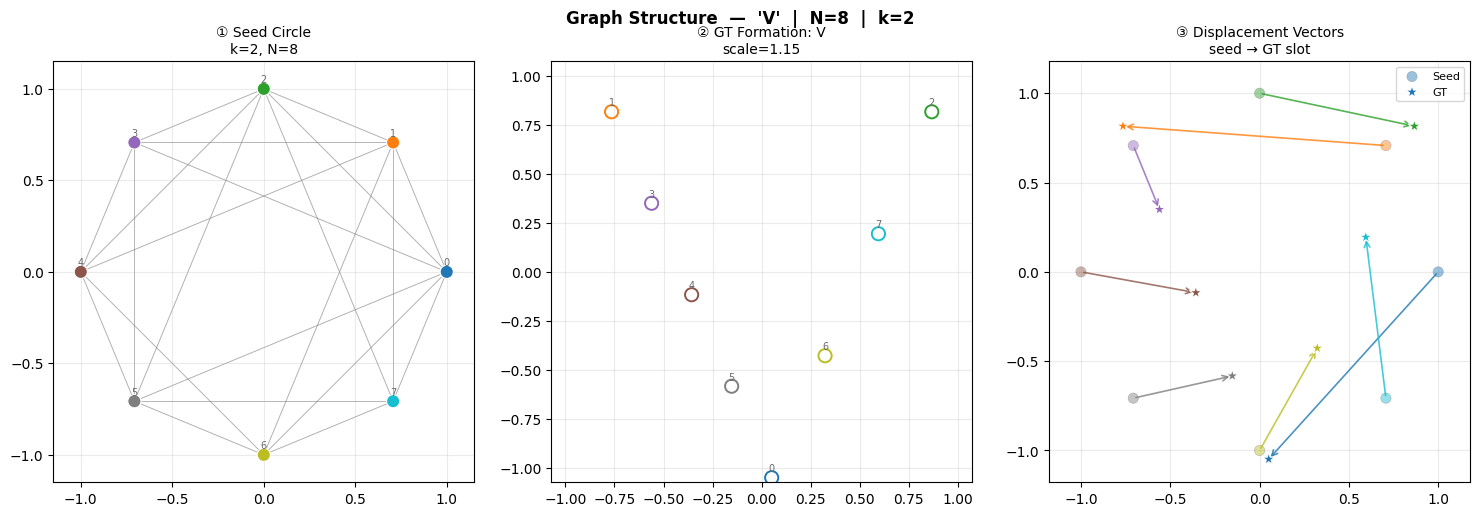

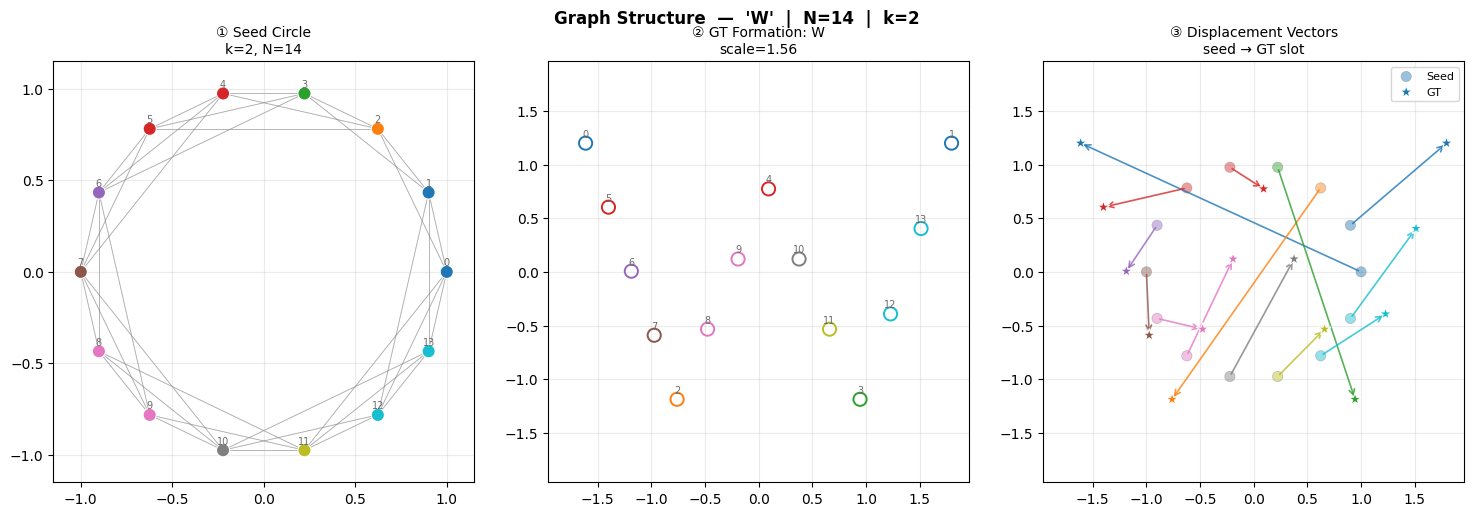

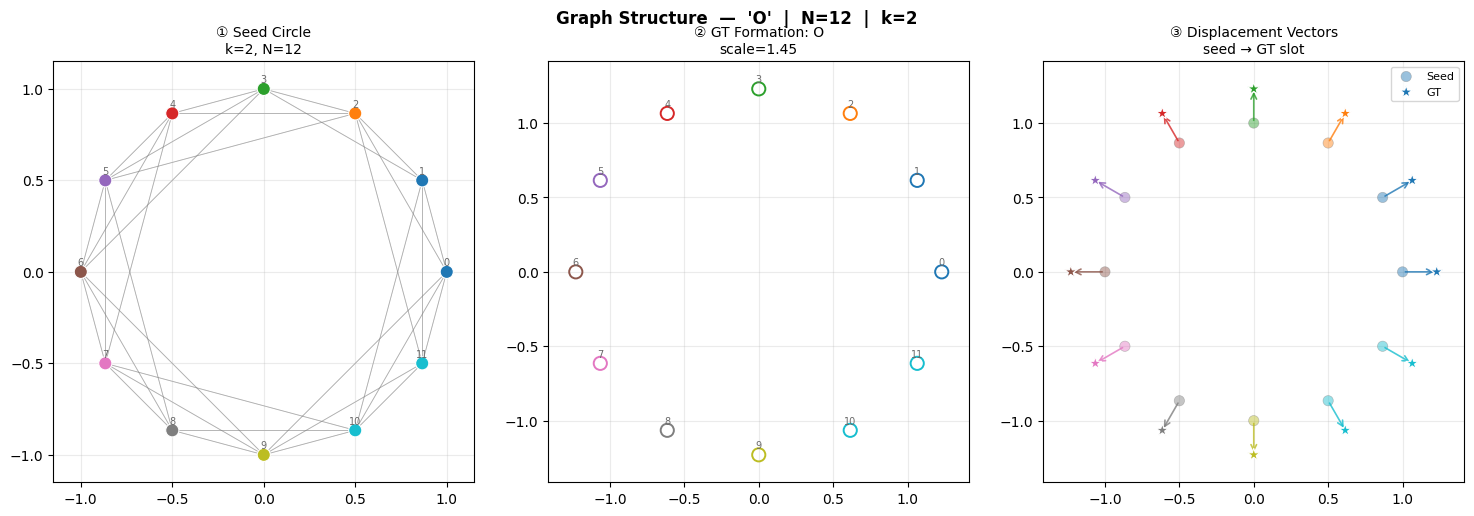

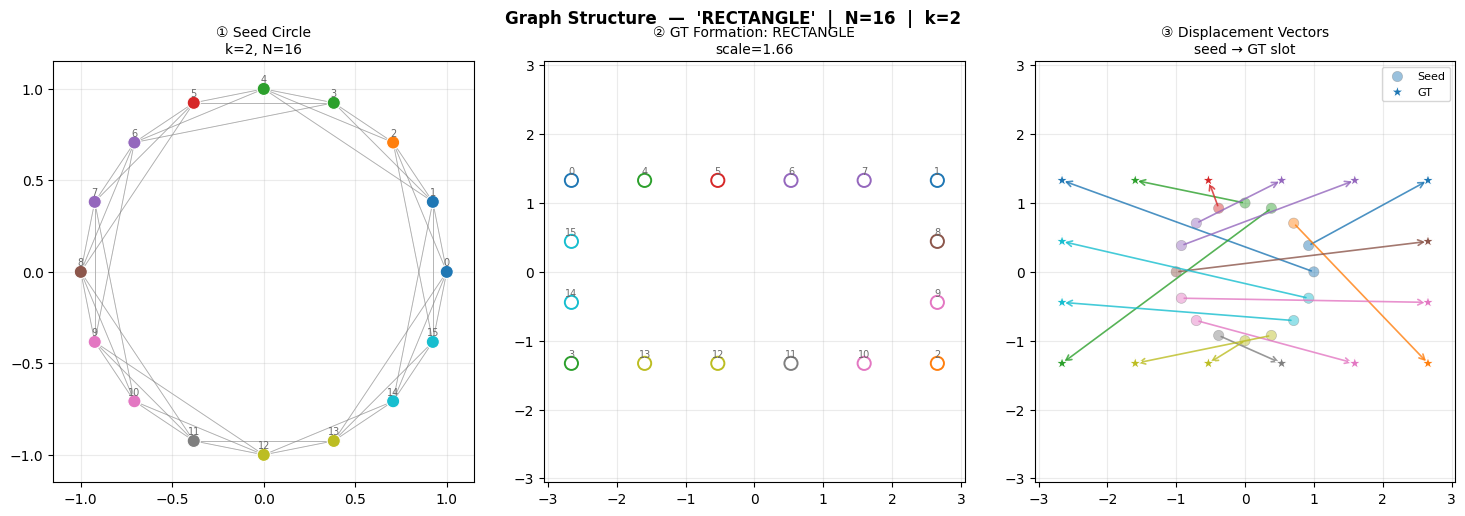

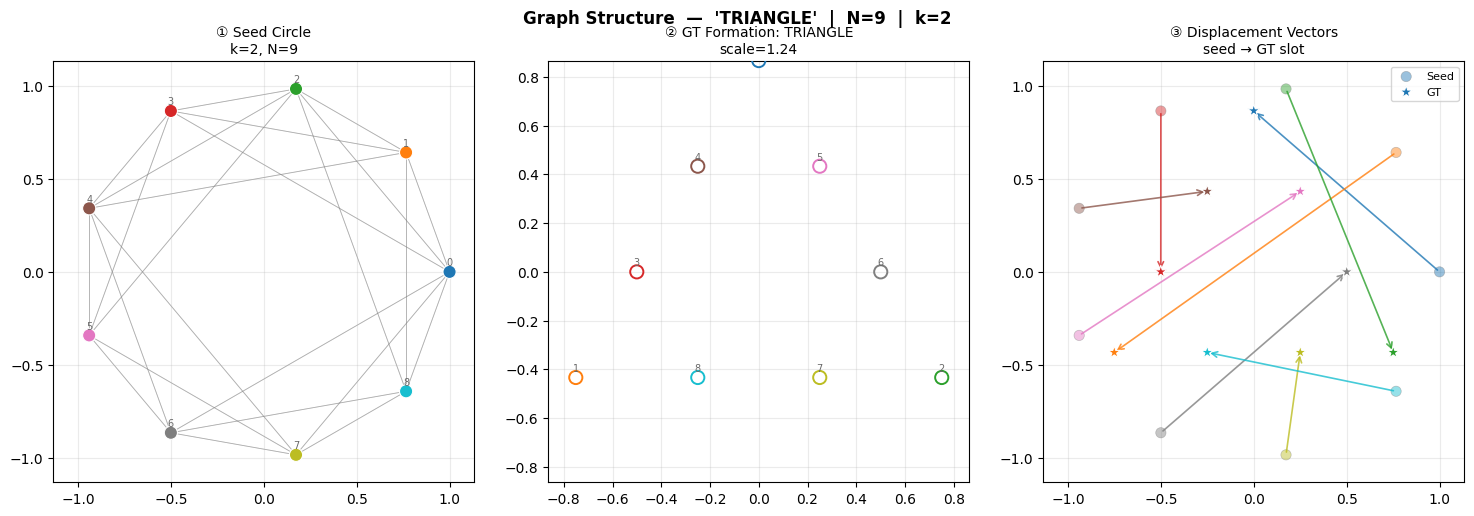

    Saved 6 graph-structure figures


In [14]:
# ── 12. Graph structure diagrams ──────────────────────────────────────────────────
print('[3] Graph structure (seed | GT | displacement)')
for fid, n_demo in [(0,10),(1,8),(2,14),(3,12),(4,16),(5,9)]:
    fig = visualize_graph_structure(n=n_demo, formation_id=fid)
    fig.savefig(f'../figs/fig3_graph_{ID_TO_NAME[fid]}_N{n_demo}_V10.png',
                dpi=140, bbox_inches='tight')
    plt.show()
print('    Saved 6 graph-structure figures')

[4] Generating 300-sample dataset...
    300 samples
[5] Single-sample views (one per formation)


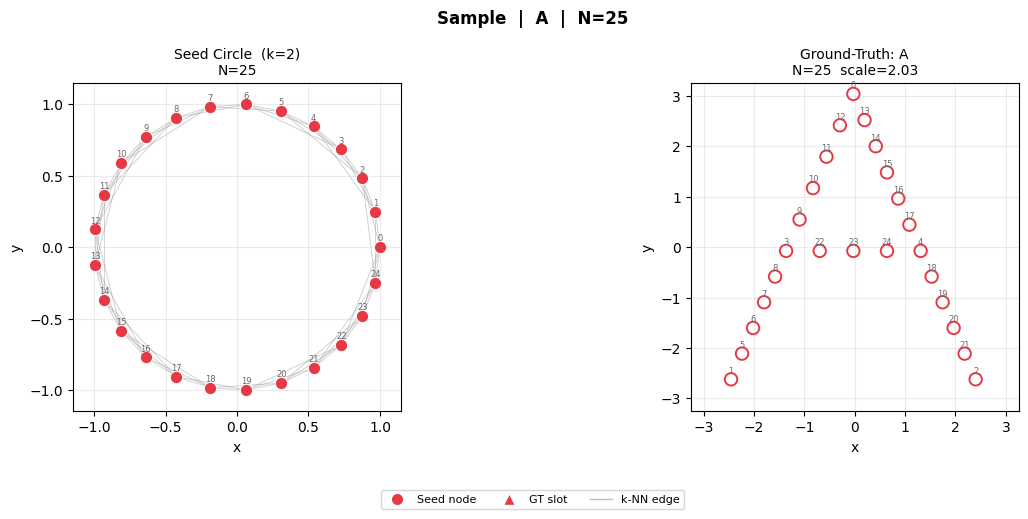

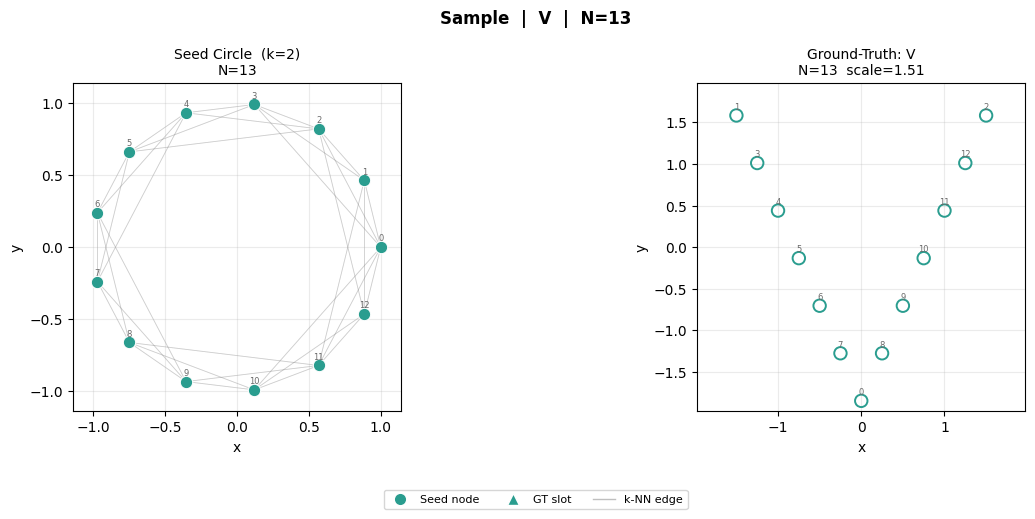

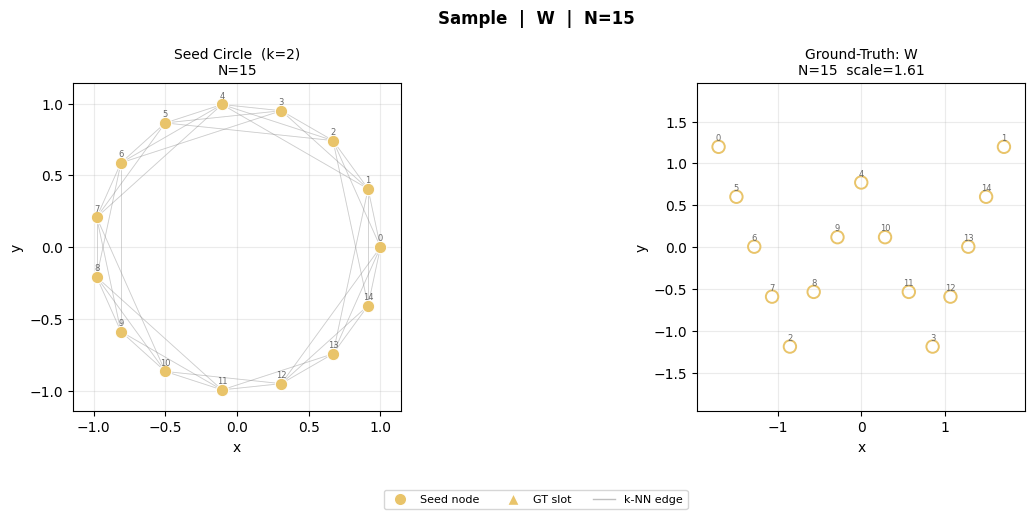

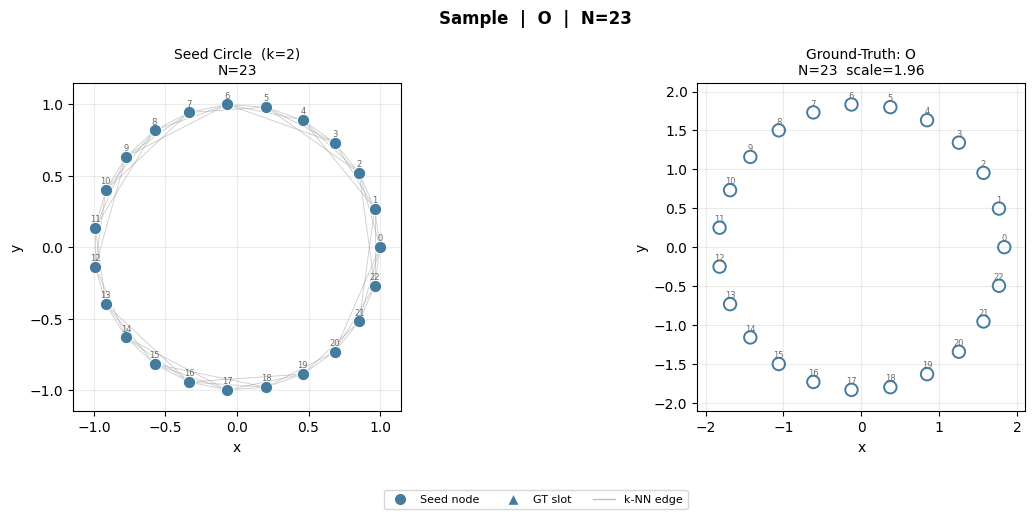

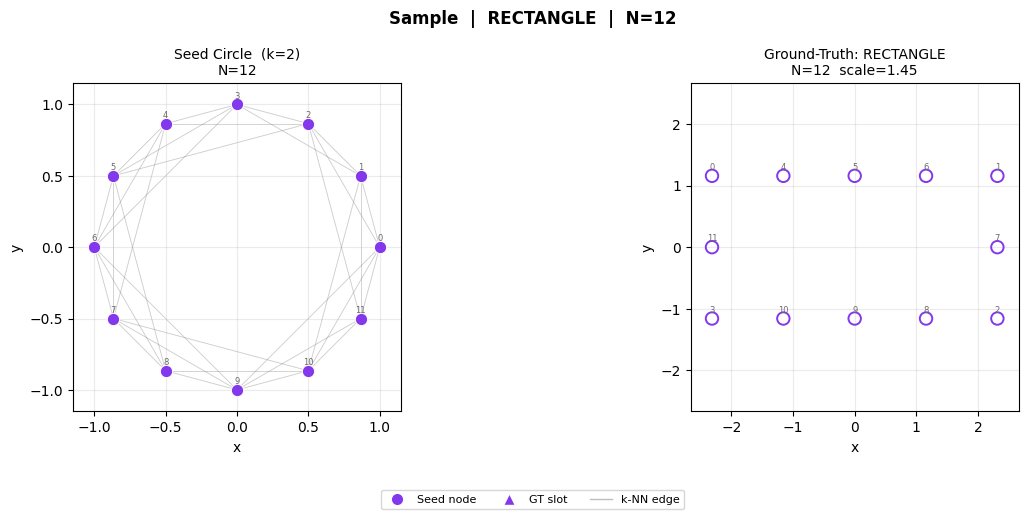

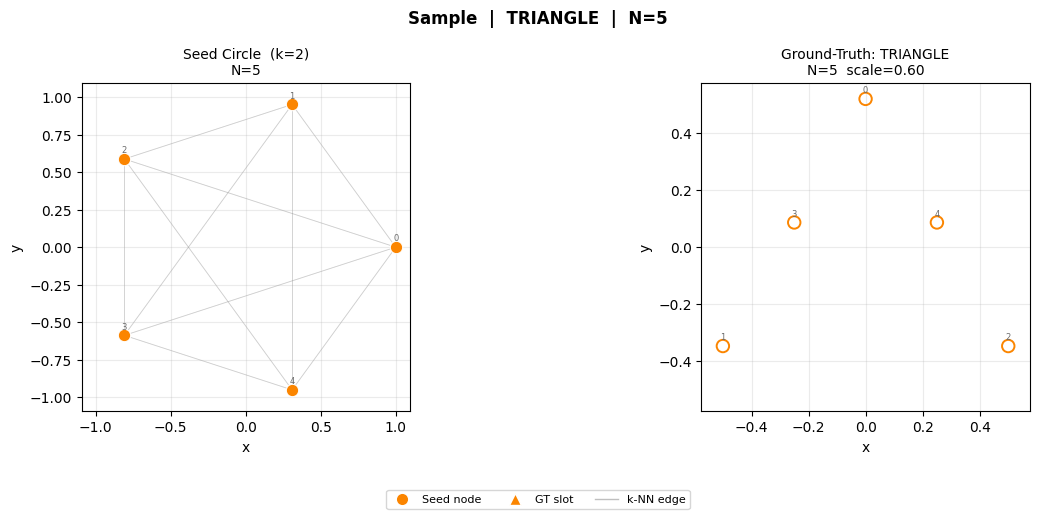

    Saved 6 single-sample figures


In [15]:
# ── 13. Mini dataset + single-sample views ────────────────────────────────────────
print('[4] Generating 300-sample dataset...')
dataset_mini = generate_dataset(300, model_stub)
print(f'    {len(dataset_mini)} samples')

print('[5] Single-sample views (one per formation)')
for fid in range(NUM_FORMATIONS):
    match = next((d for d in dataset_mini if int(d.formation_id) == fid), None)
    if match is None: continue
    fig = visualize_sample(match, show_graph=True)
    fig.savefig(f'../figs/fig4_sample_{ID_TO_NAME[fid]}_V10.png', dpi=140, bbox_inches='tight')
    plt.show()
print('    Saved 6 single-sample figures')

[6] Dataset grid + statistics


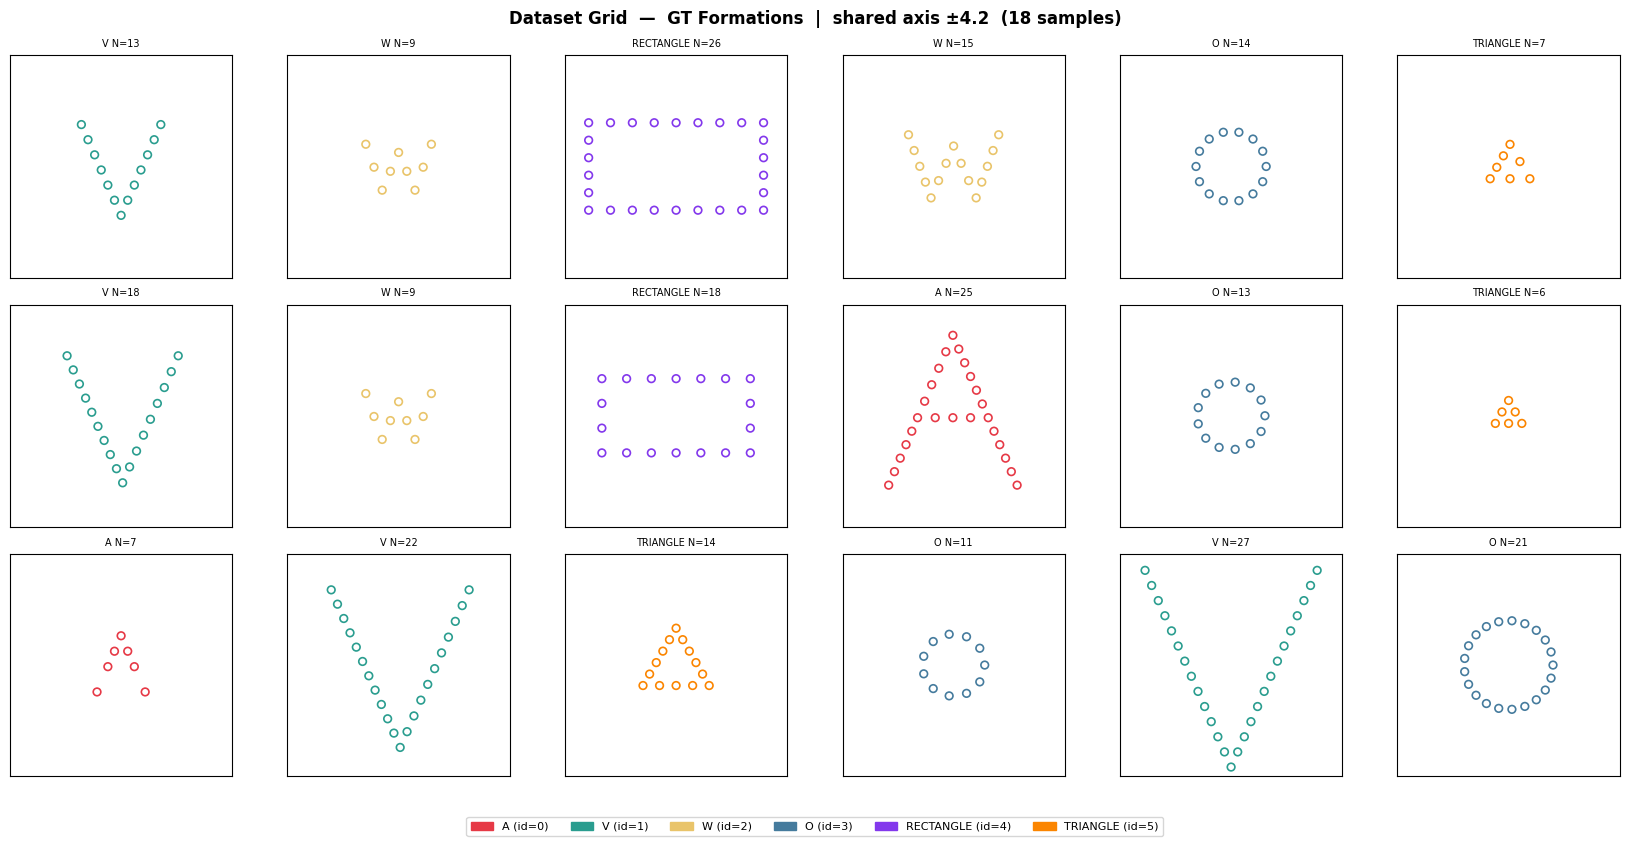

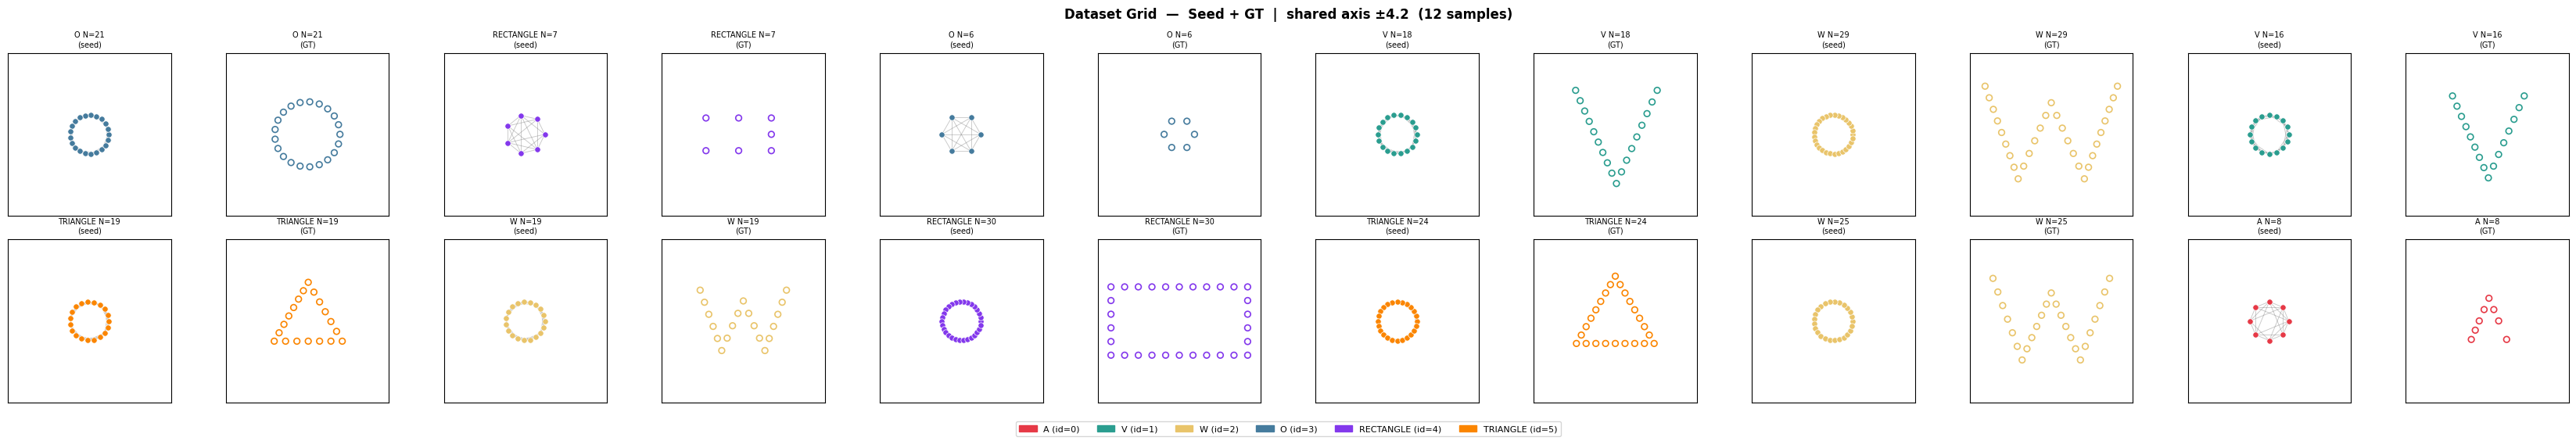

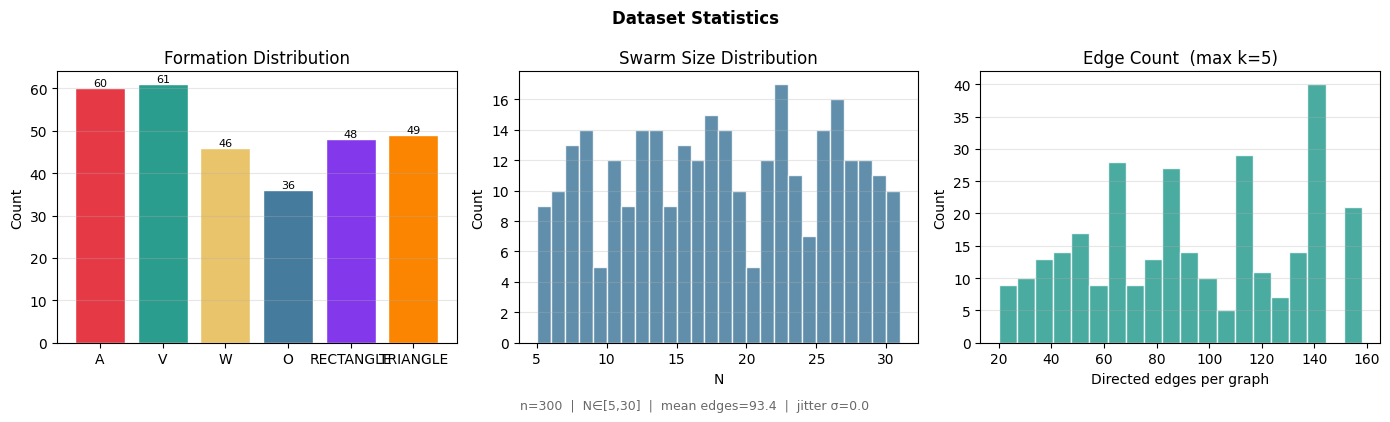

    Saved grid + statistics figures


In [16]:
# ── 14. Dataset grid & statistics ─────────────────────────────────────────────────
print('[6] Dataset grid + statistics')
fig5  = visualize_dataset_grid(dataset_mini, n_samples=18, cols=6, seed_or_gt='gt')
fig5.savefig('../figs/fig5_grid_gt_V10.png',   dpi=140, bbox_inches='tight'); plt.show()

fig5b = visualize_dataset_grid(dataset_mini, n_samples=12, cols=6, seed_or_gt='both')
fig5b.savefig('../figs/fig5b_grid_both_V10.png', dpi=140, bbox_inches='tight'); plt.show()

fig6  = dataset_statistics(dataset_mini)
fig6.savefig('../figs/fig6_statistics_V10.png', dpi=140, bbox_inches='tight'); plt.show()
print('    Saved grid + statistics figures')

In [17]:
# ── 15. Generate & save 10 000-sample training dataset ────────────────────────────
print('[7] Generating 10 000-sample dataset...')
dataset_10k = generate_dataset(10_000, model_stub)

ns_10k   = [int(d.n_drones) for d in dataset_10k]
fids_10k = [int(d.formation_id) for d in dataset_10k]
e_10k    = [d.edge_index.shape[1] for d in dataset_10k]

print(f'    samples      : {len(dataset_10k)}')
print(f'    N range      : [{min(ns_10k)}, {max(ns_10k)}]  mean={np.mean(ns_10k):.1f}')
print(f'    edges/graph  : mean={np.mean(e_10k):.1f}  min={min(e_10k)}  max={max(e_10k)}')
for fid in range(NUM_FORMATIONS):
    cnt = fids_10k.count(fid)
    print(f'      {ID_TO_NAME[fid]:10s}: {cnt} samples ({100*cnt/len(dataset_10k):.1f}%)')

torch.save(dataset_10k, '../dataset/architect_dataset_10k_V10.pt')
print('\n✅  Saved → ../dataset/architect_dataset_10k_V10.pt')
print('✅  All done.')

[7] Generating 10 000-sample dataset...
    samples      : 10000
    N range      : [5, 30]  mean=17.6
    edges/graph  : mean=92.6  min=20  max=158
      A         : 1662 samples (16.6%)
      V         : 1644 samples (16.4%)
      W         : 1611 samples (16.1%)
      O         : 1732 samples (17.3%)
      RECTANGLE : 1623 samples (16.2%)
      TRIANGLE  : 1728 samples (17.3%)

✅  Saved → ../dataset/architect_dataset_10k_V10.pt
✅  All done.
